<a href="https://colab.research.google.com/github/shruti06754/sales-forecasting-system/blob/main/sales_forecasting_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
pd.set_option('display.max_columns', None)
print("Libraries loaded successfully.")


Libraries loaded successfully.


In [13]:
USE_UPLOADED_CSV = False
if USE_UPLOADED_CSV:
  from google.colab import files
  uploaded =files.upload()
  filename = next(iter(uploaded))
  df_raw = pd.read_csv(filename)
  print("Uploaded:", filename)
else:
  # Create a realistic daily retail-sales dataset
   np.random.seed(42)
   dates =pd.date_range("2022-01-01", "2024-12-31", freq="D")
   n = len(dates)

In [14]:
trend = np.linspace(0, 1800, n)
yearly = 1800 * np.sin(2*np.pi*dates.dayofyear.to_numpy()/365.25)
weekly = 700 * np.sin(2*np.pi*dates.dayofweek.to_numpy()/7)
noise = np.random.normal(0, 450, n)

# Extra seasonal uplift around major shopping periods
month = dates.month.to_numpy()
holiday_boost = np.where(np.isin(month, [11, 12]), 1800, 0)

sales = 12000 + trend + yearly + weekly + holiday_boost + noise
sales = np.maximum(sales, 1000)

df_raw = pd.DataFrame({"Date": dates, "Sales": sales})

df_raw.head()


,Date,Sales
0,2022-01-01,11572.034666
1,2022-01-02,11454.059371
2,2022-01-03,12387.599374
3,2022-01-04,13361.336715
4,2022-01-05,12738.286850


In [18]:
df = df_raw.copy()

#Standardise common column names

rename_map = {}
for c in df.columns:
  cl = c.strip().lower().replace("","_")
if cl =="date":
     rename_map[c] = "Date"
elif cl in ["sales", "weekly_sales", "sales_amount", "sales_amount_quantity"]:
    rename_map[c]= "Sales"

df = df.rename(columns=rename_map)

if "Sales" not in df.columns:
  raise ValueError("Your CSV must contain a Sales or Weekly_Sales column.")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

df = df.dropna(subset=["Date", "Sales"])
df = df.drop_duplicates()
df = df.groupby("Date", as_index=False)["Sales"].sum()
df = df.sort_values("Date").reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Missing values:")
print(df.isna().sum())
df.head()


Rows after cleaning: 1096
Missing values:
Date     0
Sales    0
dtype: int64


,Date,Sales
0,2022-01-01,11572.034666
1,2022-01-02,11454.059371
2,2022-01-03,12387.599374
3,2022-01-04,13361.336715
4,2022-01-05,12738.286850


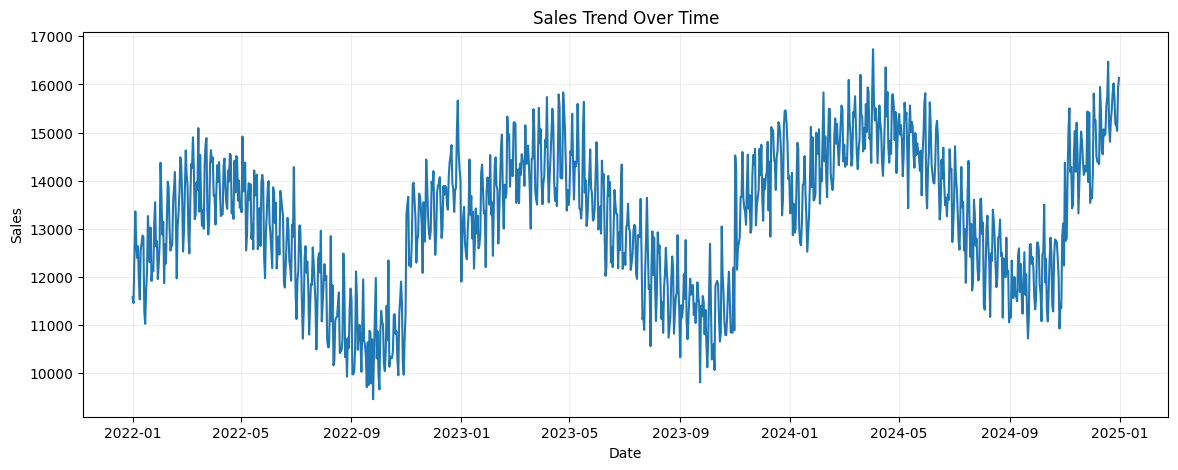

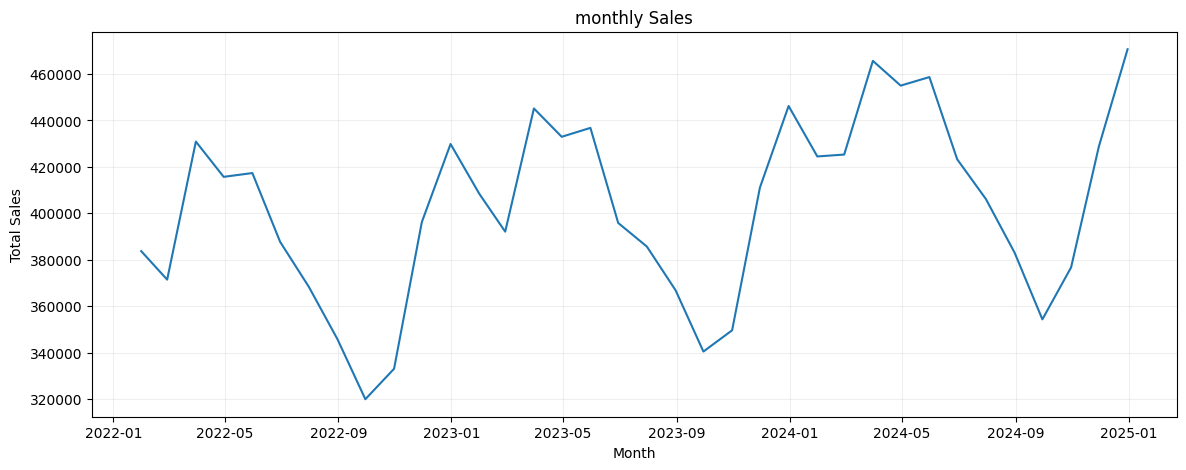

Highest sales date: 2024-04-02 00:00:00
“Highest sales value: 16732.26
Lowest sales date: 2022-09-25 00:00:00
Lowest sales value: 9457.44


In [19]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Sales"])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(alpha=0.2)
plt.show()

monthly = df.set_index("Date")["Sales"].resample("ME").sum()

plt.figure(figsize=(14,5))
plt.plot(monthly.index, monthly.values)
plt.title("monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(alpha=0.2)
plt.show()

print("Highest sales date:", df.loc[df["Sales"].idxmax(), "Date"])
print("“Highest sales value:", round(df["Sales"].max(), 2))
print("Lowest sales date:", df.loc[df["Sales"].idxmin(), "Date"])
print("Lowest sales value:", round(df["Sales"].min(), 2))


In [20]:
# Copy the original dataframe
data = df.copy()

# -----------------------------
# Time-based Features
# -----------------------------
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["DayOfWeek"] = data["Date"].dt.dayofweek
data["DayOfYear"] = data["Date"].dt.dayofyear
data["WeekOfYear"] = data["Date"].dt.isocalendar().week.astype(int)

# -----------------------------
# Lag Features
# -----------------------------
for lag in [1, 7, 14, 28]:
    data[f"Lag_{lag}"] = data["Sales"].shift(lag)

# -----------------------------
# Rolling Features
# Using only past sales
# -----------------------------
data["RollingMean_7"] = (
    data["Sales"].shift(1).rolling(7).mean()
)

data["RollingMean_28"] = (
    data["Sales"].shift(1).rolling(28).mean()
)

# Remove rows containing NaN values
data = data.dropna().reset_index(drop=True)

# -----------------------------
# Select Features
# -----------------------------
features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "RollingMean_7",
    "RollingMean_28"
]

# Input features
X = data[features]

# Target variable
y = data["Sales"]

# Display selected features
print("Features:", features)

# Display first 5 rows
data.head()

Features: ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_28', 'RollingMean_7', 'RollingMean_28']


,Date,Sales,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,Lag_1,Lag_7,Lag_14,Lag_28,RollingMean_7,RollingMean_28
0,2022-01-29,11954.471325,2022,1,29,5,29,4,12743.593313,11915.542304,11023.679479,11572.034666,12610.004787,12385.883569
1,2022-01-30,12257.369663,2022,1,30,6,30,4,11954.471325,12213.014085,11713.544238,11454.059371,12615.566075,12399.542021
2,2022-01-31,12693.588681,2022,1,31,0,31,5,12257.369663,12118.883709,12089.450519,12387.599374,12621.902586,12428.231675
3,2022-02-01,14373.335871,2022,2,1,1,32,5,12693.588681,13092.228453,13265.133162,13361.336715,12704.003297,12439.159864
4,2022-02-02,13696.797805,2022,2,2,2,33,5,14373.335871,13551.959518,12881.331523,12738.286850,12887.018642,12475.302691


In [21]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# --------------------------------
# Time-based Train/Test Split
# Never shuffle time-series data
# --------------------------------
split = int(len(data) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# --------------------------------
# Build Random Forest Model
# --------------------------------
model = RandomForestRegressor(
    n_estimators=250,
    random_state=42,
    n_jobs=-1,
    max_depth=18,
    min_samples_leaf=2
)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully.")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Model trained successfully.
Training rows: 854
Testing rows: 214


In [22]:
# -----------------------------
# Predict the Historical Test Period
# -----------------------------

test_pred = model.predict(X_test)

# -----------------------------
# Create Actual vs Predicted Table
# -----------------------------

comparison = pd.DataFrame({
    "Date": data.loc[X_test.index, "Date"].values,
    "Actual": y_test.values,
    "Predicted": test_pred
})

# Display first 10 predictions
comparison.head(10)

,Date,Actual,Predicted
0,2024-06-01,13425.290588,14558.081629
1,2024-06-02,14225.063783,13984.424795
2,2024-06-03,14583.558332,14559.937525
3,2024-06-04,15628.997528,15102.371946
4,2024-06-05,15169.668928,15204.943358
5,2024-06-06,14340.016127,15046.291499
6,2024-06-07,14133.363304,14227.785667
7,2024-06-08,13960.852054,14130.535243
8,2024-06-09,13939.215545,14370.654917
9,2024-06-10,14318.255926,14570.889353


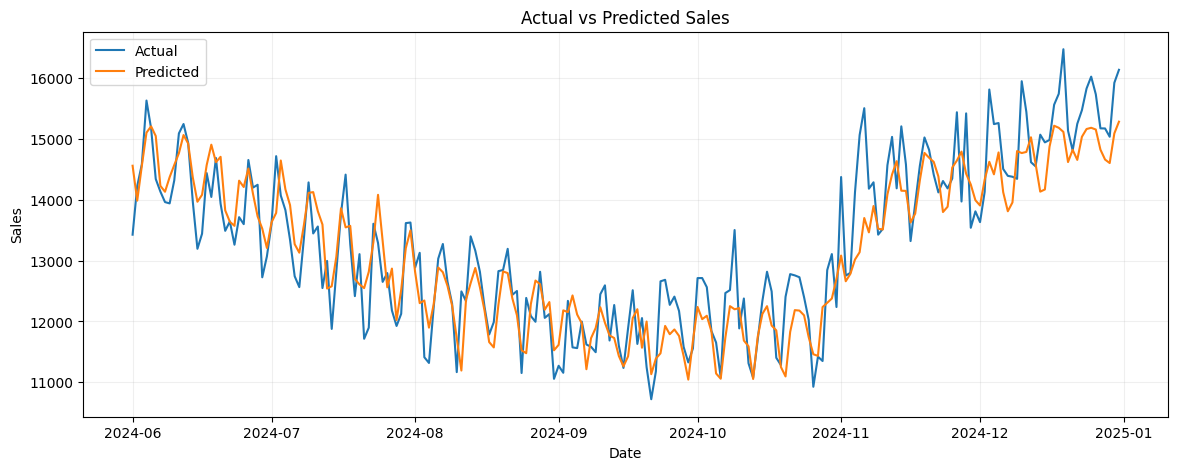

In [23]:
# -----------------------------
# Actual vs Predicted Chart
# -----------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [24]:
# -----------------------------
# Model Evaluation
# -----------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, test_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")

MAE  : 465.62
RMSE : 579.49


In [25]:
# -----------------------------
# 30-Day Future Sales Forecast
# -----------------------------

history = (
    df[["Date", "Sales"]]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

future_rows = []

# Predict the next 30 days
for _ in range(30):

    # Next date
    next_date = history["Date"].iloc[-1] + pd.Timedelta(days=1)

    # Sales history
    s = history["Sales"]

    # Create features for the next day
    row = {
        "Year": next_date.year,
        "Month": next_date.month,
        "Day": next_date.day,
        "DayOfWeek": next_date.dayofweek,
        "DayOfYear": next_date.dayofyear,
        "WeekOfYear": int(next_date.isocalendar().week),

        "Lag_1": s.iloc[-1],
        "Lag_7": s.iloc[-7],
        "Lag_14": s.iloc[-14],
        "Lag_28": s.iloc[-28],

        "RollingMean_7": s.iloc[-7:].mean(),
        "RollingMean_28": s.iloc[-28:].mean()
    }

    # Predict sales
    pred = model.predict(
        pd.DataFrame([row])[features]
    )[0]

    # Store prediction
    future_rows.append({
        "Date": next_date,
        "Predicted_Sales": pred
    })

    # Add predicted value to history
    history = pd.concat(
        [
            history,
            pd.DataFrame({
                "Date": [next_date],
                "Sales": [pred]
            })
        ],
        ignore_index=True
    )

# Create final forecast DataFrame
future_forecast = pd.DataFrame(future_rows)

# Display 30-day forecast
future_forecast.head(30)

,Date,Predicted_Sales
0,2025-01-01,15283.618732
1,2025-01-02,15562.592445
2,2025-01-03,14791.934259
3,2025-01-04,14520.173096
4,2025-01-05,14382.511343
5,2025-01-06,14708.358900
6,2025-01-07,15331.801830
7,2025-01-08,15298.014412
8,2025-01-09,15050.390566
9,2025-01-10,14649.536786


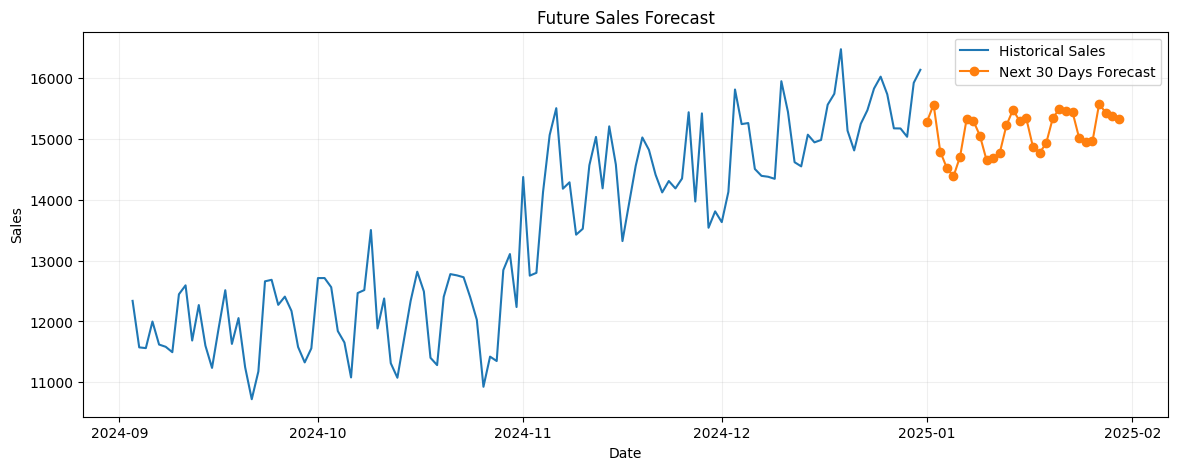

Average predicted sales for next 30 days: 15109.18


In [26]:
# -----------------------------
# Future Forecast Visualization
# -----------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Historical sales - last 120 days
plt.plot(
    df["Date"].tail(120),
    df["Sales"].tail(120),
    label="Historical Sales"
)

# Future 30-day forecast
plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Sales"],
    marker="o",
    label="Next 30 Days Forecast"
)

plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

# -----------------------------
# Average Predicted Sales
# -----------------------------

average_sales = future_forecast["Predicted_Sales"].mean()

print(
    "Average predicted sales for next 30 days:",
    round(average_sales, 2)
)

In [27]:
# -----------------------------
# Save Forecast for Submission
# -----------------------------

future_forecast.to_csv(
    "sales_forecast_30_days.csv",
    index=False
)

comparison.to_csv(
    "actual_vs_predicted.csv",
    index=False
)

print("Files saved:")
print("- sales_forecast_30_days.csv")
print("- actual_vs_predicted.csv")

Files saved:
- sales_forecast_30_days.csv
- actual_vs_predicted.csv


In [28]:
from google.colab import files

files.download("sales_forecast_30_days.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download("actual_vs_predicted.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>